# RFM Segmentation

In this notebook, we perform initial Data Cleaning and Exploratory Data Analysis on the `Online Retail.xlsx` dataset.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load the Dataset
First, we load the dataset.

In [2]:
# Load the Excel dataset
df = pd.read_excel('Online Retail.xlsx')

# Display the first few rows
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## 2. Data Cleaning

### 2.1 Checking for missing values (especially in CustomerID)

In [3]:
# Check for missing values in all columns
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

# Percentage of missing CustomerID
missing_customer_id_pct = (df['CustomerID'].isnull().sum() / len(df)) * 100
print(f"\nPercentage of missing CustomerID: {missing_customer_id_pct:.2f}%")

Missing values in each column:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Percentage of missing CustomerID: 24.93%


### 2.2 Handling rows with missing CustomerID
Since CustomerID is crucial for understanding individual customer behavior, we drop rows where it is missing.

In [4]:
# Remove rows with missing CustomerID
df_cleaned = df.dropna(subset=['CustomerID']).copy()

print(f"Original dataset size: {len(df)}")
print(f"Cleaned dataset size: {len(df_cleaned)}")

Original dataset size: 541909
Cleaned dataset size: 406829


### 2.3 Identifying and removing duplicate entries

In [5]:
# Check for duplicates
duplicates = df_cleaned.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

# Remove duplicates
df_cleaned = df_cleaned.drop_duplicates()
print(f"Dataset size after removing duplicates: {len(df_cleaned)}")

Number of duplicate rows: 5225
Dataset size after removing duplicates: 401604


### 2.4 Checking for negative quantities and unit prices
Negative quantities typically indicate returns or canceled orders. We will filter them out for the sales EDA.

In [6]:
# Check for negative or zero quantities
negative_qty = (df_cleaned['Quantity'] <= 0).sum()
print(f"Rows with Quantity <= 0: {negative_qty}")

# Check for negative or zero unit prices
negative_price = (df_cleaned['UnitPrice'] <= 0).sum()
print(f"Rows with UnitPrice <= 0: {negative_price}")

# Filter to keep only positive quantities and unit prices
df_cleaned = df_cleaned[(df_cleaned['Quantity'] > 0) & (df_cleaned['UnitPrice'] > 0)].copy()
print(f"Dataset size after keeping only positive values: {len(df_cleaned)}")

Rows with Quantity <= 0: 8872
Rows with UnitPrice <= 0: 40
Dataset size after keeping only positive values: 392692


### 2.5 Converting 'InvoiceDate' to datetime objects

In [7]:
# Convert InvoiceDate to datetime
df_cleaned['InvoiceDate'] = pd.to_datetime(df_cleaned['InvoiceDate'])

print("Data types after conversion:")
print(df_cleaned.dtypes)

Data types after conversion:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object


## 3. Exploratory Data Analysis (EDA)

### 3.1 Descriptive statistics for Quantity and UnitPrice

In [8]:
# Descriptive statistics
df_cleaned[['Quantity', 'UnitPrice']].describe()

,Quantity,UnitPrice
count,392692.000000,392692.000000
mean,13.119702,3.125914
std,180.492832,22.241836
min,1.000000,0.001000
25%,2.000000,1.250000
50%,6.000000,1.950000
75%,12.000000,3.750000
max,80995.000000,8142.750000


### 3.2 Calculation of 'TotalSales'

In [9]:
# Calculate TotalSales (Quantity * UnitPrice)
df_cleaned['TotalSales'] = df_cleaned['Quantity'] * df_cleaned['UnitPrice']

df_cleaned[['InvoiceNo', 'Quantity', 'UnitPrice', 'TotalSales']].head()

,InvoiceNo,Quantity,UnitPrice,TotalSales
0,536365,6,2.55,15.30
1,536365,6,3.39,20.34
2,536365,8,2.75,22.00
3,536365,6,3.39,20.34
4,536365,6,3.39,20.34


### 3.3 Visualizations

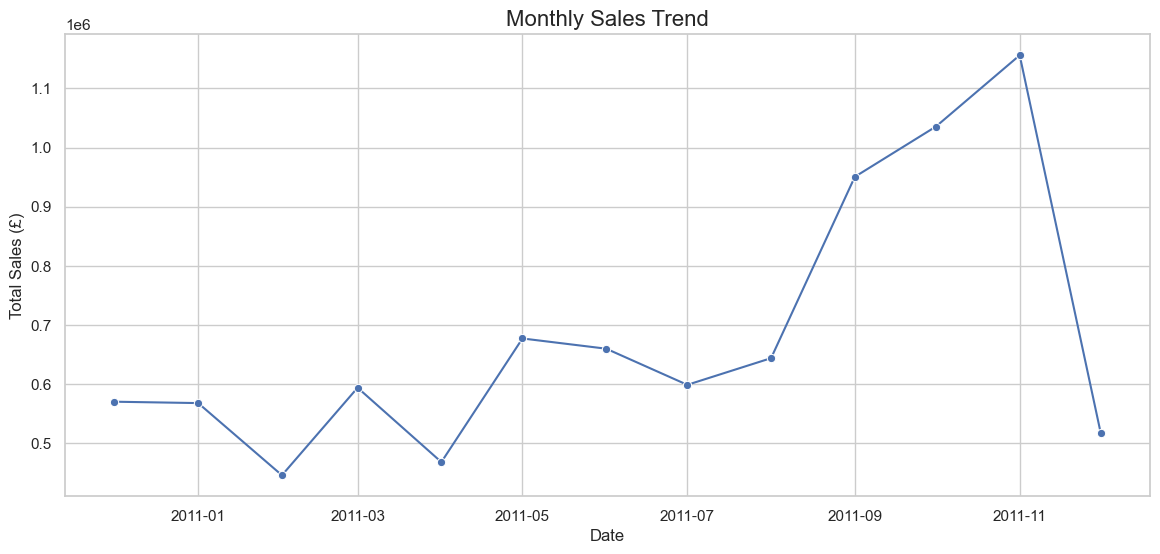

In [10]:
# 1. Sales trend over time
df_cleaned.set_index('InvoiceDate', inplace=True)
monthly_sales = df_cleaned['TotalSales'].resample('MS').sum()

plt.figure(figsize=(14, 6))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')
plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales (£)', fontsize=12)
plt.grid(True)
plt.show()

df_cleaned.reset_index(inplace=True)

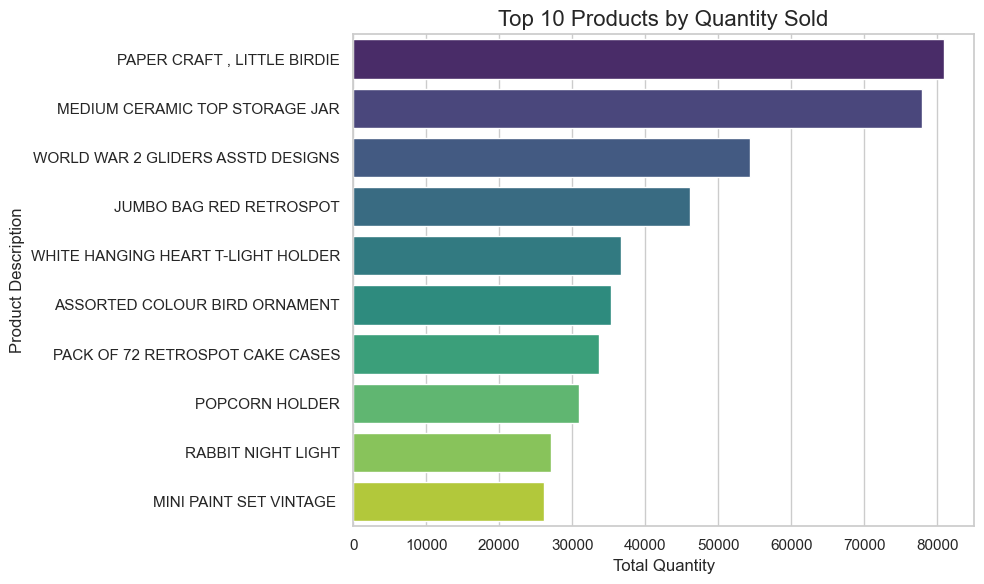

In [11]:
# 2. Top 10 products sold (by total quantity)
top_products = df_cleaned.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, hue=top_products.index, palette='viridis', legend=False)
plt.title('Top 10 Products by Quantity Sold', fontsize=16)
plt.xlabel('Total Quantity', fontsize=12)
plt.ylabel('Product Description', fontsize=12)
plt.tight_layout()
plt.show()

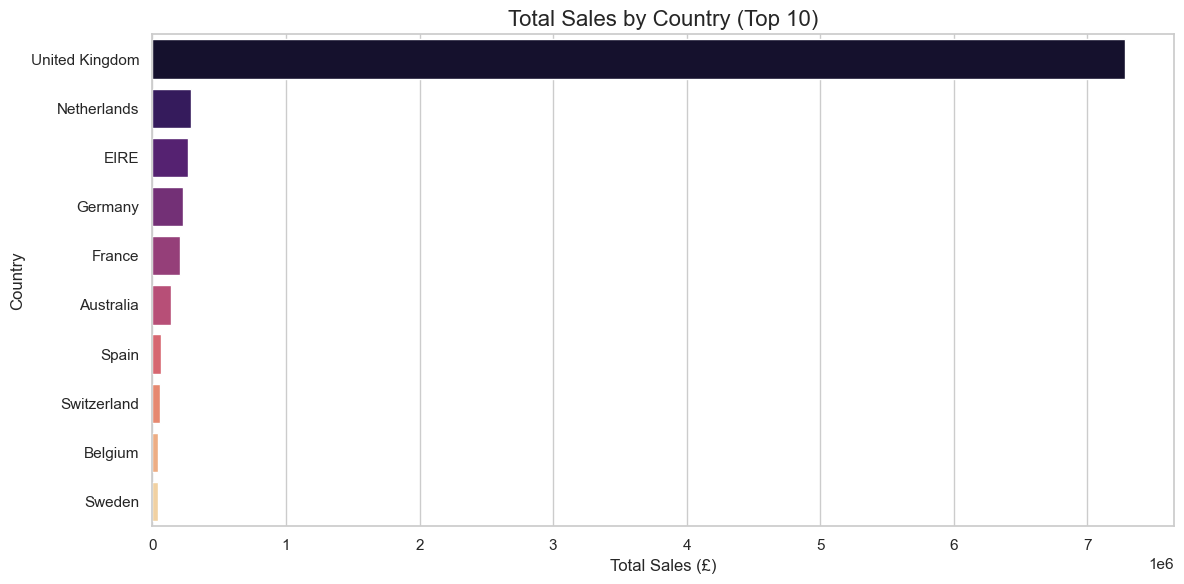

In [12]:
# 3. Sales distribution by country (Top 10)
sales_by_country = df_cleaned.groupby('Country')['TotalSales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=sales_by_country.values, y=sales_by_country.index, hue=sales_by_country.index, palette='magma', legend=False)
plt.title('Total Sales by Country (Top 10)', fontsize=16)
plt.xlabel('Total Sales (£)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.tight_layout()
plt.show()

## 4. RFM Segmentation

In this section, we will segment UK customers based on their Recency, Frequency, and Monetary (RFM) values, using data from Dec 1st 2010 to Nov 30th 2011.

In [13]:
# Filter data for United Kingdom and specific date range
rfm_data = df_cleaned[df_cleaned['Country'] == 'United Kingdom'].copy()
rfm_data = rfm_data[(rfm_data['InvoiceDate'] >= '2010-12-01') & (rfm_data['InvoiceDate'] < '2011-12-01')]

print(f"Data size for RFM: {len(rfm_data)}")

Data size for RFM: 333680


### 4.1 Calculate RFM Metrics

In [14]:
max_date = rfm_data['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = rfm_data.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (max_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalSales': 'sum'
}).rename(columns={'InvoiceDate': 'Recency', 'InvoiceNo': 'Frequency', 'TotalSales': 'Monetary'})

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,317,1,77183.60
12747.0,14,10,3757.51
12748.0,1,200,32054.19
12749.0,14,4,3327.82
12820.0,36,3,731.99


### 4.2 Handling Outliers

Before scoring, it is a good practice to handle outliers in Recency, Frequency, and Monetary to prevent them from skewing the quantile binning. We will visualize them using boxplots and apply a typical 1st and 99th percentile clipping to mitigate extreme values.

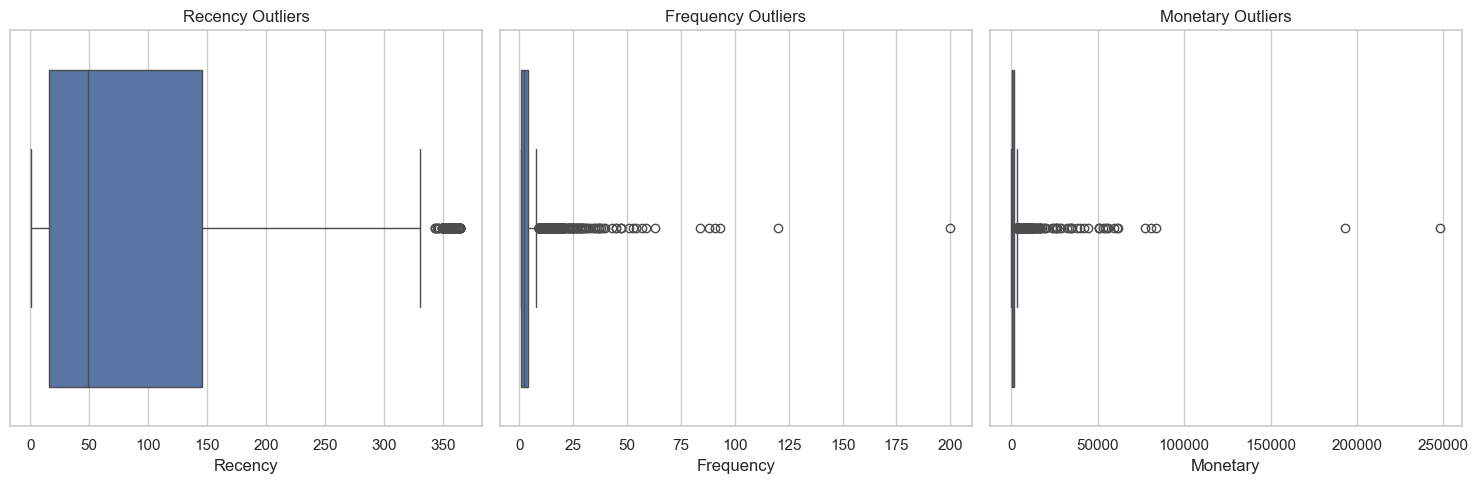

In [15]:
# Visualize Outliers with Boxplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.boxplot(x=rfm['Recency'], ax=axes[0]).set_title('Recency Outliers')
sns.boxplot(x=rfm['Frequency'], ax=axes[1]).set_title('Frequency Outliers')
sns.boxplot(x=rfm['Monetary'], ax=axes[2]).set_title('Monetary Outliers')
plt.tight_layout()
plt.show()

In [16]:
# Handle Outliers by capping at 1st and 99th percentiles
columns = ['Recency', 'Frequency', 'Monetary']

for col in columns:
    lower_bound = rfm[col].quantile(0.01)
    upper_bound = rfm[col].quantile(0.99)
    # Clip values
    rfm[col] = rfm[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers handled! Distribution after capping:")
rfm[columns].describe()

Outliers handled! Distribution after capping:


,Recency,Frequency,Monetary
count,3886.000000,3886.000000,3886.000000
mean,91.189578,3.872105,1431.441856
std,98.064915,4.628584,2413.332971
min,1.000000,1.000000,49.650000
25%,16.000000,1.000000,291.910000
50%,49.000000,2.000000,627.770000
75%,146.000000,4.000000,1514.912500
max,361.300000,28.000000,16783.712000


### 4.3 Calculate RFM Scores (1 to 100)

In [17]:
rfm['R_Score'] = pd.qcut(rfm['Recency'].rank(method='first'), 100, labels=range(100, 0, -1)).astype(int)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 100, labels=range(1, 101)).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 100, labels=range(1, 101)).astype(int)

# Weights: 50% Recency, 20% Frequency, 30% Monetary
rfm['RFM_Score'] = (rfm['R_Score'] * 0.5 + rfm['F_Score'] * 0.2 + rfm['M_Score'] * 0.3).round().astype(int)

rfm[['R_Score', 'F_Score', 'M_Score', 'RFM_Score']].head()

,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,
12346.0,4,1,100,32
12747.0,80,92,93,86
12748.0,100,99,100,100
12749.0,80,67,91,81
12820.0,58,55,56,57


### 4.4 Assign Segments based on RFM Score

We define the following segments based on the overall RFM score (1-100):
- **Champions**: Top tier customers (Score >= 80)
- **Loyal Customers**: Frequent high spenders (Score 60-79)
- **At Risk**: Have not purchased recently (Score 40-59)
- **Last chance**: Lowest tier (Score < 40)

In [18]:
def segment_customer(score):
    if score >= 80: return 'Champions'
    elif score >= 60: return 'Loyal Customers'
    elif score >= 40: return 'At Risk'
    else: return 'Last chance'
    
rfm['Segment'] = rfm['RFM_Score'].apply(segment_customer)

# Display the first few rows of the final RFM table
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,317.0,1,16783.712,4,1,100,32,Last chance
12747.0,14.0,10,3757.510,80,92,93,86,Champions
12748.0,1.0,28,16783.712,100,99,100,100,Champions
12749.0,14.0,4,3327.820,80,67,91,81,Champions
12820.0,36.0,3,731.990,58,55,56,57,At Risk


### 4.5 Distribution of Customer Segments

/var/folders/rp/vldf0xqd7rz1kcxdp15y37bm0000gp/T/ipykernel_87100/3981412767.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


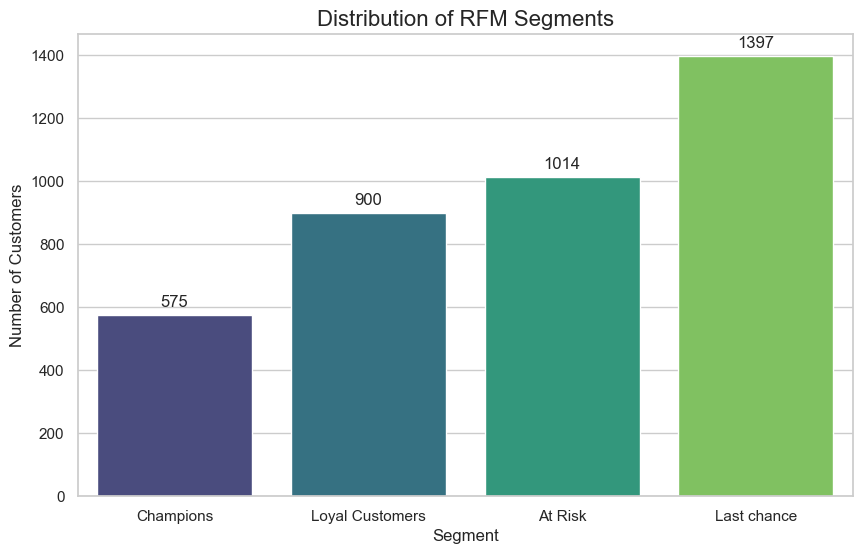

In [19]:
segment_counts = rfm['Segment'].value_counts().reset_index()
segment_counts.columns = ['Segment', 'Count']

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=segment_counts, 
    x='Segment', 
    y='Count', 
    palette='viridis', 
    order=['Champions', 'Loyal Customers', 'At Risk', 'Last chance']
)
plt.title('Distribution of RFM Segments', fontsize=16)
plt.xlabel('Segment', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)

# Add annotations
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')
plt.show()

### 4.5 Segment Summary Profile

Let's generate a summary table detailing the total customer count, share of customers, total sales, share of sales, along with the average Recency, Frequency, and Monetary values per segment.

In [20]:
segment_summary = rfm.groupby('Segment').agg(
    Customer_Count=('Recency', 'count'),
    Total_Sales=('Monetary', 'sum'),
    Mean_Recency=('Recency', 'mean'),
    Mean_Frequency=('Frequency', 'mean'),
    Mean_Monetary=('Monetary', 'mean')
).reset_index()

# Calculate shares
total_customers = segment_summary['Customer_Count'].sum()
total_sales = segment_summary['Total_Sales'].sum()

segment_summary['Customer_Share (%)'] = (segment_summary['Customer_Count'] / total_customers * 100).round(2)
segment_summary['Sales_Share (%)'] = (segment_summary['Total_Sales'] / total_sales * 100).round(2)

# Reorder columns
segment_summary = segment_summary[[
    'Segment', 'Customer_Count', 'Customer_Share (%)', 
    'Total_Sales', 'Sales_Share (%)', 
    'Mean_Recency', 'Mean_Frequency', 'Mean_Monetary'
]]

# Sort by Segment
segment_summary['Segment'] = pd.Categorical(
    segment_summary['Segment'], 
    categories=['Champions', 'Loyal Customers', 'At Risk', 'Last chance'], 
    ordered=True
)
segment_summary = segment_summary.sort_values('Segment')

# Format columns for clear display
format_dict = {
    'Total_Sales': '£{:,.2f}',
    'Mean_Recency': '{:.1f}',
    'Mean_Frequency': '{:.1f}',
    'Mean_Monetary': '£{:,.2f}'
}

segment_summary.style.format(format_dict).hide(axis='index')

Segment,Customer_Count,Customer_Share (%),Total_Sales,Sales_Share (%),Mean_Recency,Mean_Frequency,Mean_Monetary
Champions,575,14.800000,"£2,750,312.46",49.440000,8.4,11.4,"£4,783.15"
Loyal Customers,900,23.160000,"£1,521,560.68",27.350000,26.5,4.6,"£1,690.62"
At Risk,1014,26.090000,"£826,091.60",14.850000,62.7,2.4,£814.69
Last chance,1397,35.950000,"£464,618.31",8.350000,187.6,1.3,£332.58
